In [75]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

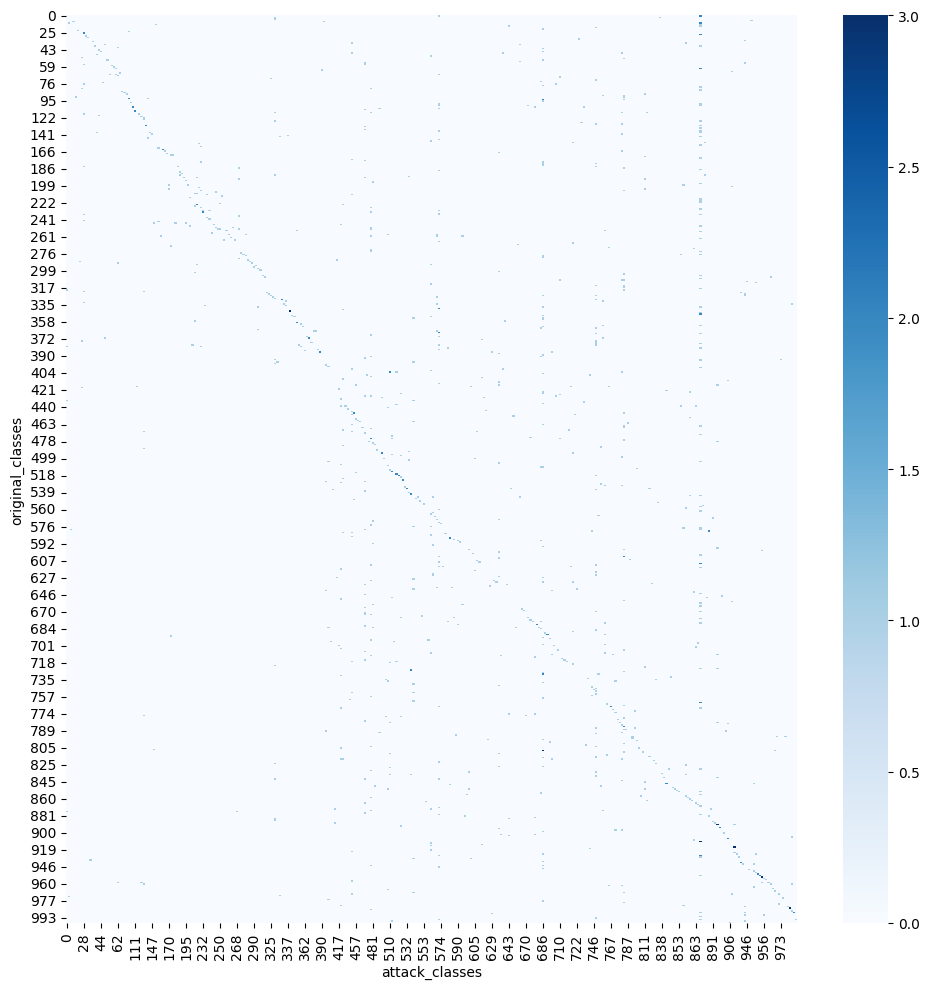

In [76]:
original = np.load(
    "log/resnet50_1024_123_live_reload.npy"
).squeeze(1)

sucess = np.load("log/resnet50_1024_123_live_injected.npy").squeeze(
    1
)

max_original = []
max_sucess = []

for a,b in zip(original,sucess):
    max_original.append(a.argmax())
    max_sucess.append(b.argmax())
    
df = pd.DataFrame({
    "original_classes":max_original,
    "attack_classes":max_sucess,
})

pd.crosstab(df.original_classes,df.attack_classes).to_csv(f"cross.csv")

plt.figure(figsize=(10, 10))
cross = pd.crosstab(df.original_classes, df.attack_classes)
sns.heatmap(cross, fmt='d', cmap='Blues')
plt.tight_layout()
plt.savefig(f"cross.png")
